## Install Dependencies

In [1]:
!pip install transformers datasets torch scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Import Torch, Check for GPU

In [2]:
import torch

# Check if GPU is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available. Using:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("GPU not available, using CPU.")

GPU is available. Using: NVIDIA A100-SXM4-40GB


## Read from GitHub

In [3]:
import pandas as pd

# URL to access the raw CSV data
url = 'https://raw.githubusercontent.com/eteitelbaum/code-satp/refs/heads/main/data/perpetrator.csv'

try:
    df = pd.read_csv(url)
    print(df.head())
except Exception as e:
    print(f"Error loading CSV from URL: {e}")

  perpetrator                                   incident_summary
0    Security  An alleged arms supplier to the Communist Part...
1      Maoist  A Kamareddy dalam (squad) member belonging to ...
2    Security  Senior CPI-Maoist 'Polit Bureau' and 'central ...
3      Maoist  A TDP leader and former Sarpanch of Jerrela Gr...
4      Maoist  The CPI-Maoist cadres blasted coffee pulping u...


## Read from Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
# Assuming your CSV file is named 'conflict_data.csv'
df = pd.read_csv('/content/drive/MyDrive/SATP_data/perpetrator.csv')

Unique values in 'perpetrator':
['Security' 'Maoist' 'Unknown']


## Clean Data

In [4]:

# Select only the necessary columns
df = df[['incident_summary', 'perpetrator']]

# Drop rows with missing values
df.dropna(inplace=True)

# Assuming your DataFrame is named 'df'
unique_perpetrators = df['perpetrator'].unique()

# Display the unique values
print("Unique values in 'perpetrator':")
print(unique_perpetrators)

Unique values in 'perpetrator':
['Security' 'Maoist' 'Unknown']


## Create Training, Validation and Test Sets

In [5]:

from sklearn.model_selection import train_test_split

# Split data into training and temporary sets (test + validation)
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['perpetrator'], random_state=42)

# Split temporary set into validation and test sets
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['perpetrator'], random_state=42)

# Print the shapes of the resulting DataFrames
print("Training set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)
print("Test set shape:", test_df.shape)


Training set shape: (7931, 2)
Validation set shape: (991, 2)
Test set shape: (992, 2)


## Summarize Label-wise Counts

In [6]:
# Calculate label-wise counts for each set
train_counts = train_df['perpetrator'].value_counts()
val_counts = val_df['perpetrator'].value_counts()
test_counts = test_df['perpetrator'].value_counts()

# Print the label-wise counts for each set
print("Label-wise counts for training set:")
print(train_counts)

print("\nLabel-wise counts for validation set:")
print(val_counts)

print("\nLabel-wise counts for test set:")
test_counts


Label-wise counts for training set:
perpetrator
Maoist      4152
Security    3410
Unknown      369
Name: count, dtype: int64

Label-wise counts for validation set:
perpetrator
Maoist      519
Security    426
Unknown      46
Name: count, dtype: int64

Label-wise counts for test set:


,count
perpetrator,
Maoist,519
Security,427
Unknown,46


# old

In [ ]:
# import pandas as pd
# import torch
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, classification_report
# from transformers import (
#     AutoTokenizer,
#     AutoModelForSequenceClassification,
#     Trainer,
#     TrainingArguments
# )
# from torch.utils.data import Dataset

# # -------------------------------------------------------
# # 1. Dataset for Single-Label Multi-Class Classification
# # -------------------------------------------------------
# class SingleLabelDataset(Dataset):
#     def __init__(self, texts, labels, tokenizer, max_length=128):
#         """
#         Args:
#             texts: List of text strings.
#             labels: List of integer class labels (e.g., [0, 1, 2, ...]).
#             tokenizer: A Hugging Face AutoTokenizer.
#             max_length: Max sequence length for tokenization.
#         """
#         self.texts = texts
#         self.labels = labels
#         self.tokenizer = tokenizer
#         self.max_length = max_length

#     def __len__(self):
#         return len(self.texts)

#     def __getitem__(self, idx):
#         text = self.texts[idx]
#         label = self.labels[idx]

#         encoding = self.tokenizer(
#             text,
#             max_length=self.max_length,
#             padding="max_length",
#             truncation=True,
#             return_tensors="pt"
#         )

#         # Squeeze batch dimension
#         item = {k: v.squeeze() for k, v in encoding.items()}
#         # Integer labels for cross-entropy
#         item["labels"] = torch.tensor(label, dtype=torch.long)

#         return item

# # -------------------------------------------------------
# # 2. Custom Metric Function
# # -------------------------------------------------------
# def compute_metricss(eval_pred, label_names=None):
#     """
#     Computes accuracy and micro/macro precision/recall/F1 for multi-class classification.
#     """
#     logits, labels = eval_pred
#     preds = torch.argmax(torch.tensor(logits), dim=1).numpy()

#     # Accuracy
#     acc = accuracy_score(labels, preds)

#     # Classification Report (optionally naming classes)
#     report = classification_report(
#         labels,
#         preds,
#         target_names=label_names if label_names else None,
#         zero_division=0,
#         output_dict=True
#     )

#     if label_names:
#         print("\nFull Classification Report:\n",
#               classification_report(labels, preds, target_names=label_names, zero_division=0))
#     else:
#         print("\nFull Classification Report:\n",
#               classification_report(labels, preds, zero_division=0))
#     return {
#         "accuracy": acc,
#         "precision_macro": report["macro avg"]["precision"],
#         "recall_macro": report["macro avg"]["recall"],
#         "f1_macro": report["macro avg"]["f1-score"],
#         "precision_weighted": report["weighted avg"]["precision"],
#         "recall_weighted": report["weighted avg"]["recall"],
#         "f1_weighted": report["weighted avg"]["f1-score"],
#     }

# # -------------------------------------------------------
# # 3. Main Training Function with Train/Val/Test Splits
# # -------------------------------------------------------
# def train_multiclass_model_3way_split(
#     df,
#     text_col="incident_summary",
#     label_col="perpetrator",
#     model_name="bert-base-uncased",
#     test_size=0.1,
#     val_size=0.1,
#     epochs=2,
#     batch_size=8
# ):
#     """
#     Trains a multi-class classifier with separate train, val, and test sets.

#     Args:
#         data_path (str): CSV file path. Must contain `text_col` and `label_col`.
#         text_col (str): Name of the column containing the text.
#         label_col (str): Name of the column containing the class label (string form).
#         model_name (str): HF model identifier, e.g. 'bert-base-uncased', 'roberta-base', etc.
#         test_size (float): Fraction of entire dataset to hold out for final test set.
#         val_size (float): Fraction of entire dataset to hold out for validation set
#                           (relative to total, not just leftover).
#         epochs (int): Number of training epochs.
#         batch_size (int): Batch size for training and evaluation.

#     Returns:
#         model: The trained model (same as trainer.model).
#         tokenizer: The tokenizer used.
#         test_metrics: Evaluation metrics on the test set.
#     """

#     # 1. Load the data
#     # df = pd.read_csv(data_path)

#     # 2. Convert label from string to integer IDs
#     unique_labels = df[label_col].unique()
#     label2id = {label: i for i, label in enumerate(unique_labels)}
#     id2label = {v: k for k, v in label2id.items()}

#     df["label_id"] = df[label_col].map(label2id)

#     # 3. Create initial train+val vs test split
#     #    e.g. if test_size=0.1, then 10% of data is test, 90% is train+val
#     train_val_df, test_df = train_test_split(
#         df,
#         test_size=test_size,
#         random_state=42,
#         stratify=df["label_id"]  # optional, if you want stratified splits
#     )

#     # 4. From the train_val_df, create train vs val split
#     #    val_size is fraction of the entire dataset, so the fraction
#     #    within train_val_df is val_size / (1 - test_size).
#     val_fraction_of_trainval = val_size / (1 - test_size)
#     train_df, val_df = train_test_split(
#         train_val_df,
#         test_size=val_fraction_of_trainval,
#         random_state=42,
#         stratify=train_val_df["label_id"]
#     )

#     # 5. Prepare data lists
#     train_texts = train_df[text_col].tolist()
#     train_labels = train_df["label_id"].tolist()

#     val_texts = val_df[text_col].tolist()
#     val_labels = val_df["label_id"].tolist()

#     test_texts = test_df[text_col].tolist()
#     test_labels = test_df["label_id"].tolist()

#     # 6. Tokenizer & Model
#     tokenizer = AutoTokenizer.from_pretrained(model_name)
#     num_labels = len(unique_labels)

#     model = AutoModelForSequenceClassification.from_pretrained(
#         model_name,
#         num_labels=num_labels
#     )
#     model.to(device)


#     # 7. Create Dataset objects
#     train_dataset = SingleLabelDataset(train_texts, train_labels, tokenizer)
#     val_dataset = SingleLabelDataset(val_texts, val_labels, tokenizer)
#     test_dataset = SingleLabelDataset(test_texts, test_labels, tokenizer)

#     # 8. Training Arguments
#     training_args = TrainingArguments(
#         output_dir="./model_output",
#         num_train_epochs=epochs,
#         per_device_train_batch_size=batch_size,
#         per_device_eval_batch_size=batch_size,
#         eval_strategy="epoch",
#         save_strategy="epoch",
#         logging_dir="./logs",
#         logging_steps=10,
#         report_to="none",
#         load_best_model_at_end=False  # set to True if you'd like to restore best checkpoint
#     )

#     # 9. Create Trainer
#     label_names = [id2label[i] for i in range(num_labels)]

#     trainer = Trainer(
#         model=model,
#         args=training_args,
#         train_dataset=train_dataset,
#         eval_dataset=val_dataset,
#         compute_metrics=lambda eval_pred: compute_metricss(eval_pred, label_names=label_names)
#     )

#     # 10. Train
#     trainer.train()

#     # 11. Evaluate on the test set
#     #     By default, trainer.evaluate() returns a dictionary of metric values
#     test_metrics = trainer.evaluate(test_dataset)

#     print("\nTest Set Evaluation Results:", test_metrics)

#     # Return the final model, tokenizer, and test set metrics
#     return trainer.model, tokenizer, test_metrics



# Imports

In [7]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from torch.utils.data import Dataset
import numpy as np
from torch.nn.functional import softmax

## Datset Class for Single-Label Multiclass Classification

In [8]:
class SingleLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        """
        Args:
            texts: List of text strings.
            labels: List of integer class labels (e.g., [0, 1, 2, ...]).
            tokenizer: A Hugging Face AutoTokenizer.
            max_length: Max sequence length for tokenization.
        """
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Squeeze batch dimension
        item = {k: v.squeeze() for k, v in encoding.items()}
        # Integer labels for cross-entropy
        item["labels"] = torch.tensor(label, dtype=torch.long)

        return item

## Custom Metric Function

In [9]:
from sklearn.metrics import accuracy_score, classification_report

def compute_metricss(eval_pred, label_names=None):
    """
    Returns the entire classification_report (per-class metrics),
    as well as an 'accuracy' top-level key for easy access.
    """
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=1).numpy()

    # Accuracy
    acc = accuracy_score(labels, preds)

    # Full classification report (dict)
    # This includes one entry per label/class, plus
    #   "accuracy", "macro avg", and "weighted avg".
    report_dict = classification_report(
        labels,
        preds,
        target_names=label_names if label_names else None,
        zero_division=0,
        output_dict=True
    )

    # Print a readable version, if desired:
    if label_names:
        print("\nFull Classification Report:\n",
              classification_report(labels, preds, target_names=label_names, zero_division=0))
    else:
        print("\nFull Classification Report:\n",
              classification_report(labels, preds, zero_division=0))

    # Return a dict that:
    #   - includes a top-level 'accuracy'
    #   - stores the entire classification_report in 'class_report'
    return {
        "accuracy": acc,
        "class_report": report_dict
    }

## Main Training Function with Train/Val/Test Splits

In [10]:
def train_multiclass_model(
    train_df,
    test_df,
    val_df,
    text_col="incident_summary",
    label_col="perpetrator",
    model_name="bert-base-uncased",
    epochs=2,
    batch_size=8
):
    """
    Trains a multi-class classifier with separate train, val, and test sets.

    Args:
        data_path (str): CSV file path. Must contain `text_col` and `label_col`.
        text_col (str): Name of the column containing the text.
        label_col (str): Name of the column containing the class label (string form).
        model_name (str): HF model identifier, e.g. 'bert-base-uncased', 'roberta-base', etc.
        test_size (float): Fraction of entire dataset to hold out for final test set.
        val_size (float): Fraction of entire dataset to hold out for validation set
                          (relative to total, not just leftover).
        epochs (int): Number of training epochs.
        batch_size (int): Batch size for training and evaluation.

    Returns:
        model: The trained model (same as trainer.model).
        tokenizer: The tokenizer used.
        test_metrics: Evaluation metrics on the test set.
    """


    # Convert label from string to integer IDs
    unique_labels = train_df[label_col].unique()
    label2id = {label: i for i, label in enumerate(unique_labels)}
    id2label = {v: k for k, v in label2id.items()}

    train_df["label_id"] = train_df[label_col].map(label2id)
    val_df["label_id"] = val_df[label_col].map(label2id)
    test_df["label_id"] = test_df[label_col].map(label2id)


    # Prepare data lists
    train_texts = train_df[text_col].tolist()
    train_labels = train_df["label_id"].tolist()

    val_texts = val_df[text_col].tolist()
    val_labels = val_df["label_id"].tolist()

    test_texts = test_df[text_col].tolist()
    test_labels = test_df["label_id"].tolist()

    # Tokenizer & Model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    num_labels = len(unique_labels)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )
    model.to(device)


    #  Create Dataset objects
    train_dataset = SingleLabelDataset(train_texts, train_labels, tokenizer)
    val_dataset = SingleLabelDataset(val_texts, val_labels, tokenizer)
    test_dataset = SingleLabelDataset(test_texts, test_labels, tokenizer)

    # Training Arguments
    training_args = TrainingArguments(
        output_dir="./model_output",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_dir="./logs",
        logging_steps=10,
        report_to="none",
        load_best_model_at_end=False  # set to True if you'd like to restore best checkpoint
    )

    # Create Trainer
    label_names = [id2label[i] for i in range(num_labels)]

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=lambda eval_pred: compute_metricss(eval_pred, label_names=label_names)
    )

    # Train
    trainer.train()

    # Evaluate on the test set
    #     By default, trainer.evaluate() returns a dictionary of metric values
    test_metrics = trainer.evaluate(test_dataset)

    print("\nTest Set Evaluation Results:", test_metrics)
    # Evaluate on test set
    test_metrics = trainer.evaluate(test_dataset)
    print("\nTest Set Evaluation Results:", test_metrics)

    # === PREDICTIONS on TEST ===
    # Use trainer.predict instead of evaluate
    predictions_output = trainer.predict(test_dataset)
    logits = predictions_output.predictions
    probs = softmax(torch.tensor(logits), dim=1).numpy()
    preds = np.argmax(logits, axis=1)

    pred_df = pd.DataFrame({
        "incident_summary": test_df[text_col].tolist(),
        "true_label_id": test_labels,
        "true_label": [id2label[i] for i in test_labels],
        "pred_label_id": preds.tolist(),
        "pred_label": [id2label[i] for i in preds],
        "logits": logits.tolist(),
        "probabilities": probs.tolist()
    })

    return trainer.model, tokenizer, test_metrics, pred_df, id2label

# **Grid loop for Training cased and uncased**

In [11]:
fraction_labels = {
    1/32: "3%",   # 1/32 = 3.125%
    1/16: "6%",   # 1/16 = 6.25%
    1/8:  "12%",  # 1/8  = 12.5%
    1/4:  "25%",
    1/2:  "50%",
    1.0:  "100%"
}

model_name_labels = {
    "bert-base-uncased": "BERT Base (uncased)",
    "snowood1/ConfliBERT-scr-uncased": "ConfliBERT-scr-uncased",
    "roberta-base": "RoBERTa Base",
    "distilbert-base-uncased": "DistilBERT (uncased)",
    "xlnet-base-cased": "XLNet Base (cased)",
    "google/electra-base-discriminator": "ELECTRA Base"
}

fractions = [1/32, 1/16, 1/8, 1/4, 1/2, 1.0]

models_list = [
    "bert-base-uncased",
    "snowood1/ConfliBERT-scr-uncased",
    "roberta-base",
    "distilbert-base-uncased",
    "xlnet-base-cased",
    "google/electra-base-discriminator"
]

# Grid loop for Training **ALL CASED** and ELECTRA uncased

In [12]:
fraction_labels = {
    1/32: "3%",   # 1/32 = 3.125%
    1/16: "6%",   # 1/16 = 6.25%
    1/8:  "12%",  # 1/8  = 12.5%
    1/4:  "25%",
    1/2:  "50%",
    1.0:  "100%"
}

model_name_labels = {
    "bert-base-cased": "BERT",
    "snowood1/ConfliBERT-scr-cased": "ConfliBERT",
    "FacebookAI/roberta-base": "RoBERTa",
    "distilbert-base-cased": "DistilBERT",
    "xlnet-base-cased": "XLNet",
    "google/electra-base-discriminator": "ELECTRA"
}

fractions = [1/32, 1/16, 1/8, 1/4, 1/2, 1.0]

models_list = [
    "bert-base-cased",
    "snowood1/ConfliBERT-scr-cased",
    "FacebookAI/roberta-base",
    "distilbert-base-cased",
    "xlnet-base-cased",
    "google/electra-base-discriminator"
]


## Old Experiments Function

In [ ]:
# import pandas as pd

# def run_all_experiments_and_save(df_full, output_csv="experiment_results.csv"):
#     """
#     1. Iterates over the defined fractions & model list
#     2. Samples df_full according to fraction
#     3. Trains & evaluates using train_multiclass_model_3way_split
#     4. Saves the collected results in a DataFrame
#     5. Exports to CSV

#     Args:
#         df_full (pd.DataFrame): Full dataset with columns [label_col, text_col].
#         output_csv (str): File path to save the experiment results.
#     Returns:
#         results_df (pd.DataFrame): Contains experiment results for analysis.
#     """
#     results_list = []

#     for frac in fractions:
#         # Sample a fraction of the data
#         subset_size = int(len(df_full) * frac)
#         df_subset = df_full.sample(n=subset_size, random_state=42)

#         # Friendly fraction label if you want
#         frac_label = fraction_labels.get(frac, f"{frac*100:.1f}%")
#         print(f"\n=== DATA FRACTION: {frac} ({subset_size} rows) ===")

#         for model_name in models_list:
#             # Model label
#             model_label = model_name_labels.get(model_name, model_name)
#             print(f"Training model: {model_label}")

#             # Train & evaluate
#             model, tokenizer, test_metrics = train_multiclass_model_3way_split(
#                 df_subset,
#                 text_col="incident_summary",
#                 label_col="perpetrator",
#                 model_name=model_name,
#                 test_size=0.1,   # 10% for test
#                 val_size=0.1,   # 10% for val
#                 epochs=2,
#                 batch_size=32
#             )

#             # Build a result dict
#             run_result = {
#                 "fraction_raw": frac,
#                 "fraction_label": frac_label,
#                 "subset_size": subset_size,
#                 "model_raw": model_name,
#                 "model_label": model_label
#             }

#             # Merge test_metrics (e.g., accuracy, macro-F1, etc.)
#             for k, v in test_metrics.items():
#                 run_result[k] = v

#             # Append to results_list
#             results_list.append(run_result)

#     # Convert to DataFrame
#     results_df = pd.DataFrame(results_list)
#     # Save to CSV
#     results_df.to_csv(output_csv, index=False)
#     print(f"\nResults saved to {output_csv}")

#     # (Optionally, also save to JSON if desired)
#     # results_df.to_json("experiment_results.json", orient="records")

#     return results_df


## Define Function to Run and Save Experiments

In [13]:
def run_all_experiments_and_save(df_full, output_csv="experiment_results.csv", predictions_csv="predictions.csv"):
    """
    1. Iterates over fractions & model list
    2. Samples df_full by 'frac'
    3. Trains & evaluates using train_multiclass_model
    4. Saves results in a DataFrame, including:
       - Full classification report (flattened)
       - Training label-wise support
    5. Exports to CSV
    """
    results_list = []
    all_predictions = []

    for frac in fractions:
        subset_size = int(len(df_full) * frac)
        df_subset = df_full.sample(n=subset_size, random_state=42)

        frac_label = fraction_labels.get(frac, f"{frac*100:.1f}%")
        print(f"\n=== DATA FRACTION: {frac} ({subset_size} rows) ===")

        for model_name in models_list:
            model_label = model_name_labels.get(model_name, model_name)
            print(f"Training model: {model_label}")


            model, tokenizer, test_metrics, pred_df, id2label = train_multiclass_model(
                df_subset,
                test_df,
                val_df,
                text_col="incident_summary",
                label_col="perpetrator",
                model_name=model_name,
                epochs=2,
                batch_size=32
            )

            run_result = {
                "fraction_raw": frac,
                "fraction_label": frac_label,
                "subset_size": subset_size,
                "model_raw": model_name,
                "model_label": model_label
            }


            for key, val in test_metrics.items():
                if key == "class_report":
                    for label_name, metrics_dict in val.items():
                        if isinstance(metrics_dict, dict):
                            for metric_name, metric_value in metrics_dict.items():
                                safe_label = label_name.replace(" ", "_")
                                run_result[f"{safe_label}_{metric_name}"] = metric_value
                        else:
                            run_result[label_name] = metrics_dict
                else:
                    run_result[key] = val



            label_counts = df_subset["label_id"].value_counts()
            for label_id_val, count in label_counts.items():
                label_name = id2label[label_id_val]
                run_result[f"train_support_{label_name}"] = count

            results_list.append(run_result)

            pred_df["model"] = model_name
            pred_df["model_label"] = model_label
            pred_df["fraction"] = frac
            pred_df["fraction_label"] = frac_label
            all_predictions.append(pred_df)

    results_df = pd.DataFrame(results_list)
    results_df.to_csv(output_csv, index=False)
    full_pred_df = pd.concat(all_predictions, ignore_index=True)
    full_pred_df.to_csv(predictions_csv, index=False)

    print(f"Test results saved to {output_csv}")
    print(f"Test predictions saved to {predictions_csv}")
    return results_df, full_pred_df

## Run Training Loop

In [14]:
# Run models
final_results_df, test_predictions_df  = run_all_experiments_and_save(train_df, output_csv="experiment_results.csv", predictions_csv="predictions.csv" )

# Inspect final_results_df in Python:
print(final_results_df.head())


=== DATA FRACTION: 0.03125 (247 rows) ===
Training model: BERT


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

...


Full Classification Report:
               precision    recall  f1-score   support

      Maoist       0.98      0.97      0.97       519
    Security       0.95      0.98      0.97       427
     Unknown       0.90      0.78      0.84        46

    accuracy                           0.96       992
   macro avg       0.94      0.91      0.93       992
weighted avg       0.96      0.96      0.96       992


Test Set Evaluation Results: {'eval_loss': 0.12705108523368835, 'eval_accuracy': 0.9637096774193549, 'eval_class_report': {'Maoist': {'precision': 0.9766536964980544, 'recall': 0.9672447013487476, 'f1-score': 0.9719264278799613, 'support': 519.0}, 'Security': {'precision': 0.954337899543379, 'recall': 0.9789227166276346, 'f1-score': 0.9664739884393063, 'support': 427.0}, 'Unknown': {'precision': 0.9, 'recall': 0.782608695652174, 'f1-score': 0.8372093023255814, 'support': 46.0}, 'accuracy': 0.9637096774193549, 'macro avg': {'precision': 0.9436638653471445, 'recall': 0.90959203787618

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Class Report
1,0.164800,0.208874,0.936428,"{'Maoist': {'precision': 0.9857142857142858, 'recall': 0.930635838150289, 'f1-score': 0.9573835480673935, 'support': 519.0}, 'Security': {'precision': 0.9172259507829977, 'recall': 0.9624413145539906, 'f1-score': 0.9392898052691867, 'support': 426.0}, 'Unknown': {'precision': 0.6481481481481481, 'recall': 0.7608695652173914, 'f1-score': 0.7, 'support': 46.0}, 'accuracy': 0.9364278506559032, 'macro avg': {'precision': 0.8503627948818107, 'recall': 0.8846489059738903, 'f1-score': 0.8655577844455268, 'support': 991.0}, 'weighted avg': {'precision': 0.9406042221332857, 'recall': 0.9364278506559032, 'f1-score': 0.9376584444920795, 'support': 991.0}}"
2,0.144100,0.156950,0.959637,"{'Maoist': {'precision': 0.976878612716763, 'recall': 0.976878612716763, 'f1-score': 0.976878612716763, 'support': 519.0}, 'Security': {'precision': 0.9689737470167065, 'recall': 0.9530516431924883, 'f1-score': 0.9609467455621302, 'support': 426.0}, 'Unknown': {'precision': 0.7169811320754716, 'recall': 0.8260869565217391, 'f1-score': 0.7676767676767676, 'support': 46.0}, 'accuracy': 0.9596367305751766, 'macro avg': {'precision': 0.8876111639363137, 'recall': 0.9186724041436635, 'f1-score': 0.9018340419852203, 'support': 991.0}, 'weighted avg': {'precision': 0.9614166985919159, 'recall': 0.9596367305751766, 'f1-score': 0.9603193187917243, 'support': 991.0}}"



Full Classification Report:
               precision    recall  f1-score   support

      Maoist       0.99      0.93      0.96       519
    Security       0.92      0.96      0.94       426
     Unknown       0.65      0.76      0.70        46

    accuracy                           0.94       991
   macro avg       0.85      0.88      0.87       991
weighted avg       0.94      0.94      0.94       991


Full Classification Report:
               precision    recall  f1-score   support

      Maoist       0.98      0.98      0.98       519
    Security       0.97      0.95      0.96       426
     Unknown       0.72      0.83      0.77        46

    accuracy                           0.96       991
   macro avg       0.89      0.92      0.90       991
weighted avg       0.96      0.96      0.96       991




Full Classification Report:
               precision    recall  f1-score   support

      Maoist       0.97      0.97      0.97       519
    Security       0.96      0.97      0.97       427
     Unknown       0.84      0.83      0.84        46

    accuracy                           0.96       992
   macro avg       0.93      0.92      0.92       992
weighted avg       0.96      0.96      0.96       992


Test Set Evaluation Results: {'eval_loss': 0.13182923197746277, 'eval_accuracy': 0.9627016129032258, 'eval_class_report': {'Maoist': {'precision': 0.9728682170542635, 'recall': 0.9672447013487476, 'f1-score': 0.970048309178744, 'support': 519.0}, 'Security': {'precision': 0.962877030162413, 'recall': 0.9718969555035128, 'f1-score': 0.9673659673659674, 'support': 427.0}, 'Unknown': {'precision': 0.8444444444444444, 'recall': 0.8260869565217391, 'f1-score': 0.8351648351648352, 'support': 46.0}, 'accuracy': 0.9627016129032258, 'macro avg': {'precision': 0.9267298972203736, 'recall': 0

## Save Results

In [ ]:
import shutil
shutil.rmtree('/content/drive', ignore_errors=True)

from google.colab import drive
drive.mount('/content/drive')

In [28]:
import os

# Before saving to JSON and CSV:
#os.makedirs("/content/drive/MyDrive/SATP_data/paper/exp/perpetrator", exist_ok=True)
os.makedirs("/content/drive/MyDrive/colab/satp-results/perpetrator", exist_ok=True)

# Now save the data:
#final_results_df.to_json("/content/drive/MyDrive/SATP_data/paper/exp/perpetrator/experiment_results.json", orient="records")
#final_results_df.to_csv("/content/drive/MyDrive/SATP_data/paper/exp/perpetrator/experiment_results.csv", index=False)
final_results_df.to_csv("/content/drive/MyDrive/colab/satp-results/perpetrator_summary.csv", index=False)
test_predictions_df.to_csv("/content/drive/MyDrive/colab/satp-results/perpetrator_predictions.csv", index=False)

# **Data Analysis**

In [19]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [20]:
#read csv from drive
import pandas as pd
#df = pd.read_csv('/content/drive/MyDrive/SATP_data/paper/exp/perpetrator/experiment_results.csv')
df = pd.read_csv("/content/drive/MyDrive/colab/satp-results/perpetrator_summary.csv")

In [21]:
df.columns

Index(['fraction_raw', 'fraction_label', 'subset_size', 'model_raw',
       'model_label', 'eval_loss', 'eval_accuracy', 'eval_class_report',
       'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second',
       'epoch', 'train_support_Maoist', 'train_support_Security',
       'train_support_Unknown'],
      dtype='object')

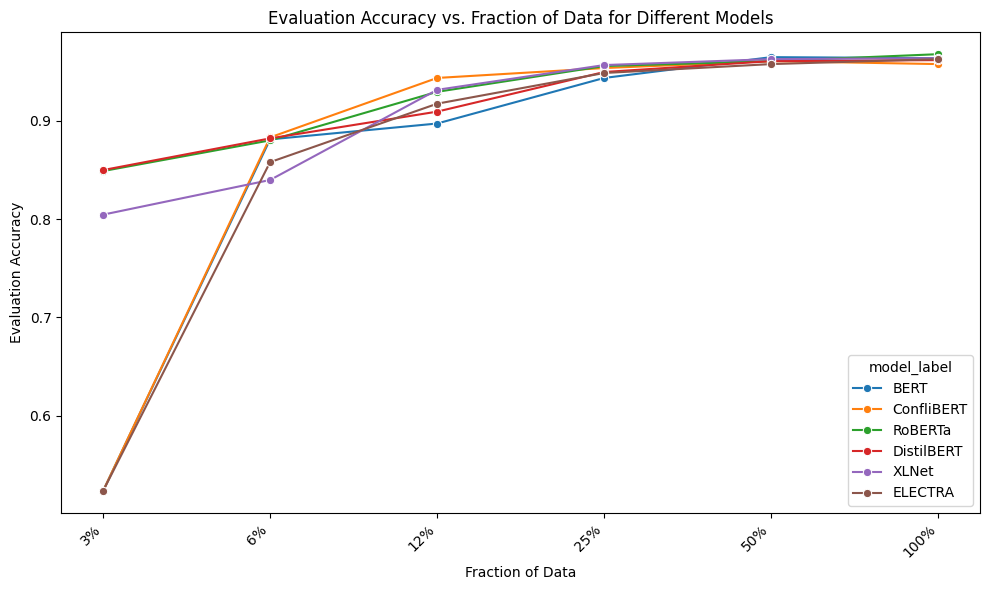

In [22]:
# prompt: fraction_label on x axis, eval_accuracy on y axis and model_label as legends for lines with different colors

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'final_results_df' is your DataFrame
# Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="fraction_label", y="eval_accuracy", hue="model_label", marker="o")

# Customize the plot
plt.xlabel("Fraction of Data")
plt.ylabel("Evaluation Accuracy")
plt.title("Evaluation Accuracy vs. Fraction of Data for Different Models")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

def scatter_plot_accuracy_vs_speed(results_df):
    """
    Creates a scatter (bubble) plot showing:
      - X-axis: eval_samples_per_second (throughput)
      - Y-axis: eval_accuracy
      - Color by model_label (hue)
      - Bubble size by fraction_raw (size)

    Assumes results_df has columns:
      - 'eval_samples_per_second'
      - 'eval_accuracy'
      - 'model_label' (string)
      - 'fraction_raw' (numeric, e.g. 0.03125, 0.0625, etc.)
    """

    # Initialize figure
    plt.figure(figsize=(8, 6))

    # Create scatterplot with Seaborn
    scatter = sns.scatterplot(
        data=results_df,
        x="eval_samples_per_second",
        y="eval_accuracy",
        hue="model_label",         # color by model
        size="fraction_raw",       # size by fraction (bubble size)
        sizes=(20, 400),          # min to max size of markers (tweak as needed)
        alpha=0.7                 # partial transparency
    )

    # Labeling
    scatter.set_title("Accuracy vs. Throughput (Samples/Sec)")
    scatter.set_xlabel("Throughput (eval_samples_per_second)")
    scatter.set_ylabel("Accuracy")

    # (Optional) Move legend to a less intrusive location
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

    # Show the plot
    plt.tight_layout()
    plt.show()


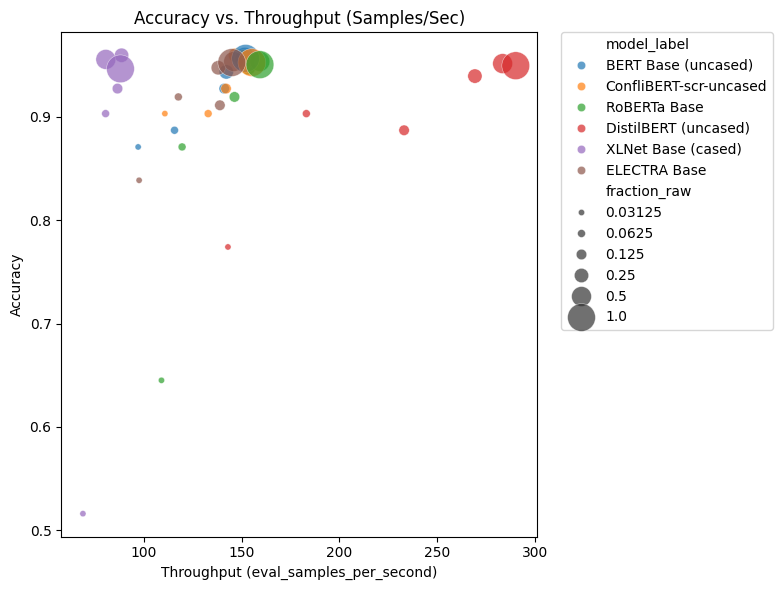

In [ ]:
scatter_plot_accuracy_vs_speed(df)

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_heatmap(results_df, value):
    """
    Creates a heatmap where:
      - Rows = Models (model_label)
      - Columns = Fractions (fraction_label)
      - Cell Values = eval_accuracy (color-coded)
    """

    # 1. Pivot the DataFrame: index=Model, columns=Fraction, values=Accuracy
    heatmap_data = results_df.pivot(
        index="model_label",
        columns="fraction_label",
        values= value
    )

    # 2. Sort columns in ascending order of fraction if you want
    heatmap_data = heatmap_data[["3%", "6%", "12%", "25%", "50%", "100%"]]

    # 3. Create the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        heatmap_data,
        annot=True,         # writes the accuracy values in each cell
        fmt=".3f",          # format for floating point
        cmap="YlGnBu",      # color palette
        cbar_kws={"label": "Accuracy"}  # colorbar label
    )

    # 4. Labeling and layout
    plt.title(f"{value} by Model and Data Fraction")
    plt.xlabel("Data Fraction")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()


In [25]:
plot_heatmap(df, "eval_f1_macro")

KeyError: 'eval_f1_macro'

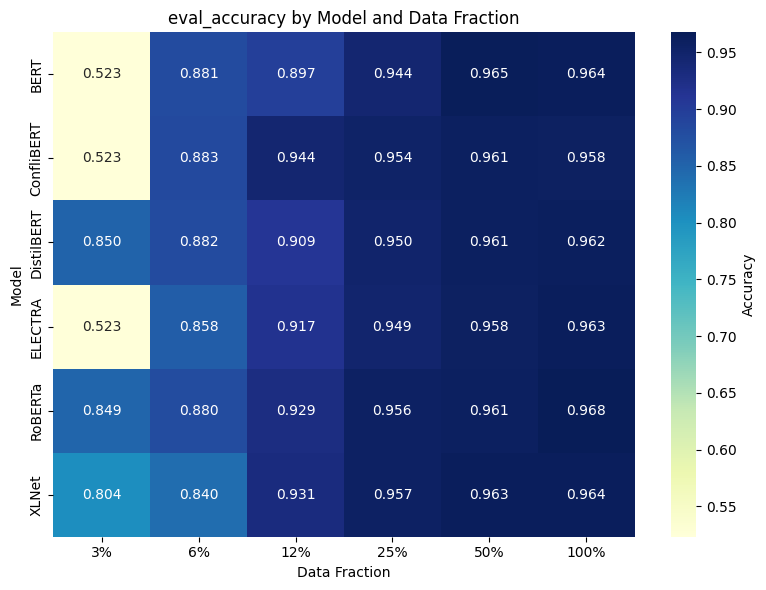

In [26]:
plot_heatmap(df, "eval_accuracy") # Change plot_heatmap_accuracy to plot_heatmap

In [27]:
plot_heatmap(df, "eval_f1_weighted") # Change plot_heatmap_accuracy to plot_heatmap

KeyError: 'eval_f1_weighted'